<a href="https://colab.research.google.com/github/hyunsoooo1103/KHUDA_Vacation_Session/blob/main/2%EC%B0%A8%EC%8B%9C_Olist_Project_ipynb%EC%9D%98_%EC%82%AC%EB%B3%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Brazilian E-Commerce by Olist 🛒 - 데이터 분석 & 예측 모델링 프로젝트

이 프로젝트는 브라질 전자상거래 플랫폼 Olist의 데이터에 대해 탐색적 데이터 분석(EDA)을 수행하고, 비즈니스 성과에 영향을 주는 주요 요인을 파악하는 것을 목표로 합니다. 통계적 인사이트와 비즈니스 관점의 결론을 함께 도출합니다.


## 🎯 비즈니스 문제

- *Olist는 여러 판매자와 브라질 전역의 고객을 연결하는 온라인 마켓플레이스입니다.*
- *이 회사는 배송 지연이라는 문제에 직면해 있습니다.*
- *배송이 늦어지면 고객 만족도와 리뷰 점수가 떨어지며, 결국 이탈률이 높아집니다. 심지어 전반적인 매출과 브랜드 평판에 타격을 줄 수도 있습니다.*
- ***Olist는 어떻게 이 문제를 해결하고 고객의 신뢰를 회복할 수 있을까요?***


# 1️⃣ Importing Library

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2️⃣ Loading Datasets

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

BASE_PATH = '/content/drive/MyDrive/olist_data'

df_customer = pd.read_csv(f'{BASE_PATH}/olist_customers_dataset.csv')
df_location = pd.read_csv(f'{BASE_PATH}/olist_geolocation_dataset.csv')
df_order_items = pd.read_csv(f'{BASE_PATH}/olist_order_items_dataset.csv')
df_order_payment = pd.read_csv(f'{BASE_PATH}/olist_order_payments_dataset.csv')
df_order_review = pd.read_csv(f'{BASE_PATH}/olist_order_reviews_dataset.csv')
df_orders = pd.read_csv(f'{BASE_PATH}/olist_orders_dataset.csv')
df_products = pd.read_csv(f'{BASE_PATH}/olist_products_dataset.csv')
df_translation = pd.read_csv(f'{BASE_PATH}/product_category_name_translation.csv')
df_sellers = pd.read_csv(f'{BASE_PATH}/olist_sellers_dataset.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 3️⃣ Data Clean



### 3.1 Customer Dataset

In [ ]:
df_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [ ]:
df_customer.isna().sum()

,0
customer_id,0
customer_unique_id,0
customer_zip_code_prefix,0
customer_city,0
customer_state,0


/tmp/ipykernel_1130/1912939728.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




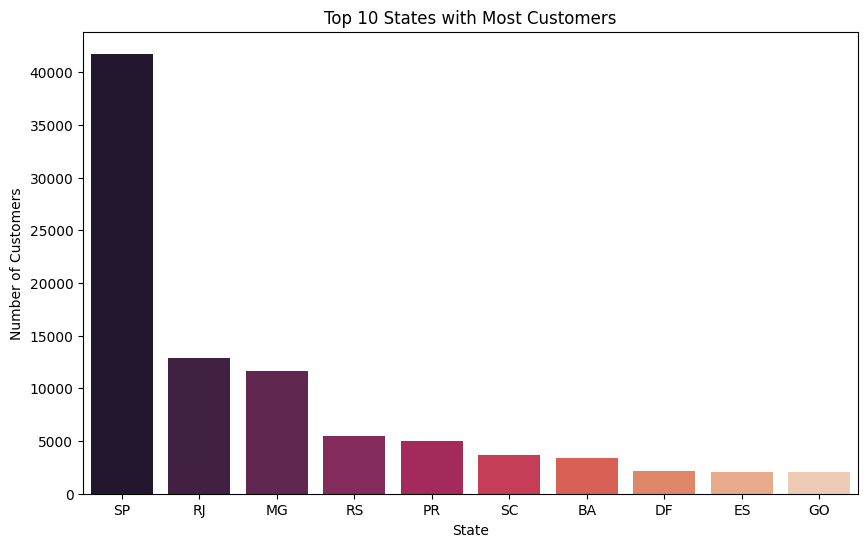

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x=df_customer['customer_state'].value_counts().head(10).index,
            y=df_customer['customer_state'].value_counts().head(10).values, palette='rocket')
plt.title('Top 10 States with Most Customers')
plt.xlabel('State')
plt.ylabel('Number of Customers')
plt.show()

### 3.2 Products Dataset


In [ ]:
df_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


- `df translation`과 left join으로 포르투갈어 카테고리명을 영어로 변환합니다.
- 번역 없는 항목은 Unknown으로 대체합니다.

In [ ]:
df_products_eng = df_products.merge(df_translation, on='product_category_name', how='left')
df_products_eng['product_category_name_english'] = df_products_eng['product_category_name_english'].fillna('Unknown')

In [ ]:
df_products_eng.isna().sum()

,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2
product_category_name_english,0


In [ ]:
df_products_eng = df_products_eng.dropna(subset=['product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty'])

In [ ]:
df_products_eng.isna().sum()

,0
product_id,0
product_category_name,0
product_name_lenght,0
product_description_lenght,0
product_photos_qty,0
product_weight_g,1
product_length_cm,1
product_height_cm,1
product_width_cm,1
product_category_name_english,0


/tmp/ipykernel_1130/2079311773.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




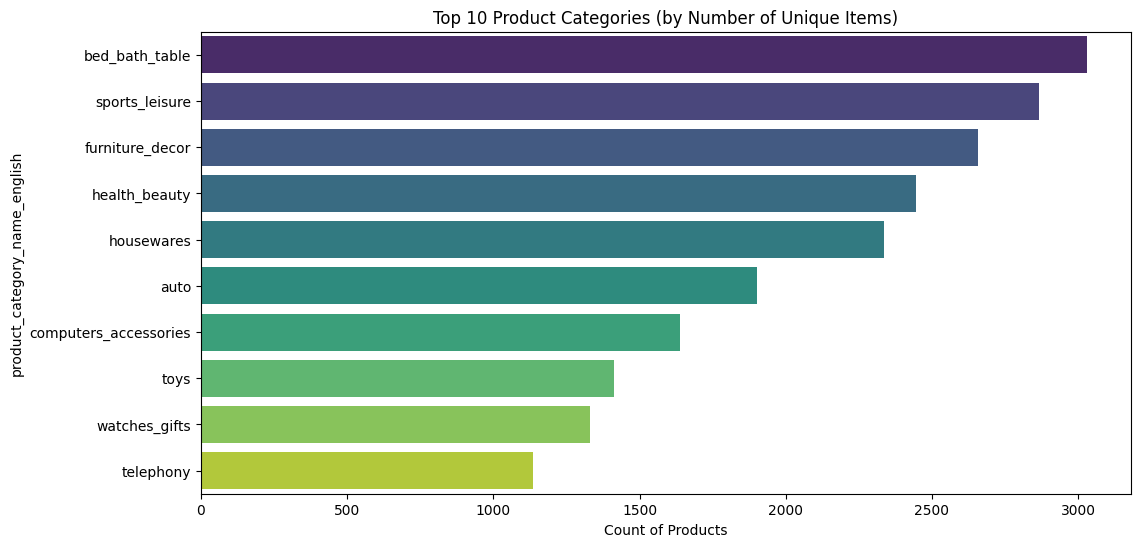

In [ ]:
plt.figure(figsize=(12, 6))
top_categories = df_products_eng['product_category_name_english'].value_counts().head(10)
sns.barplot(x=top_categories.values, y=top_categories.index, palette='viridis')
plt.title('Top 10 Product Categories (by Number of Unique Items)')
plt.xlabel('Count of Products')
plt.show()

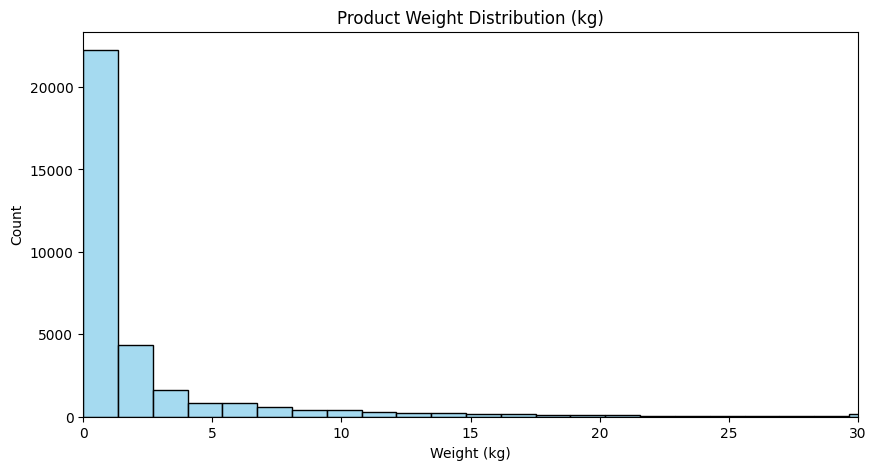

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(df_products['product_weight_g'] / 1000, bins=30, kde=False, color='skyblue')
plt.title('Product Weight Distribution (kg)')
plt.xlabel('Weight (kg)')
plt.xlim(0, 30)
plt.show()

### 3.3 Sellers Dataset

In [ ]:
df_sellers.isna().sum()

,0
seller_id,0
seller_zip_code_prefix,0
seller_city,0
seller_state,0


In [ ]:
df_sellers.duplicated().sum()

np.int64(0)

/tmp/ipykernel_1130/134741640.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




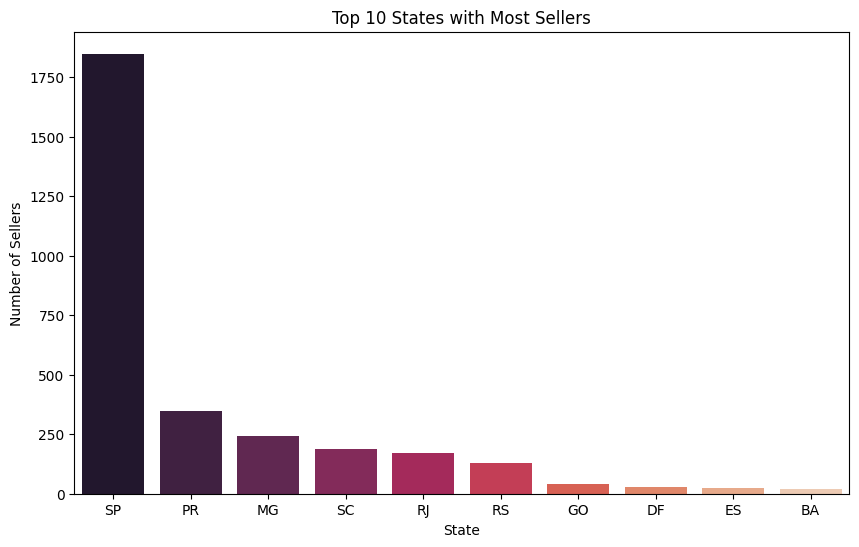

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x=df_sellers['seller_state'].value_counts().head(10).index,
            y=df_sellers['seller_state'].value_counts().head(10).values, palette='rocket')
plt.title('Top 10 States with Most Sellers')
plt.xlabel('State')
plt.ylabel('Number of Sellers')
plt.show()

### 3.4 Order Itmes Dataset

In [ ]:
df_order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [ ]:
df_order_items['shipping_limit_date'] = pd.to_datetime(df_order_items['shipping_limit_date'])

🚀 **Task 1**. 운임 비율 (freight_ratio)

- 상품 가격에 비해 배송비는 얼마나 클까요? 가격 대비 운임 비율을 계산하세요.

In [ ]:
# Write your code here
df_order_items['freight_ratio'] = df_order_items['freight_value'] / df_order_items['price']

In [ ]:
avg_ratio = df_order_items['freight_ratio'].mean()

print("평균 배송비 비율 (%):", avg_ratio * 100)

평균 배송비 비율 (%): 32.08635490797801


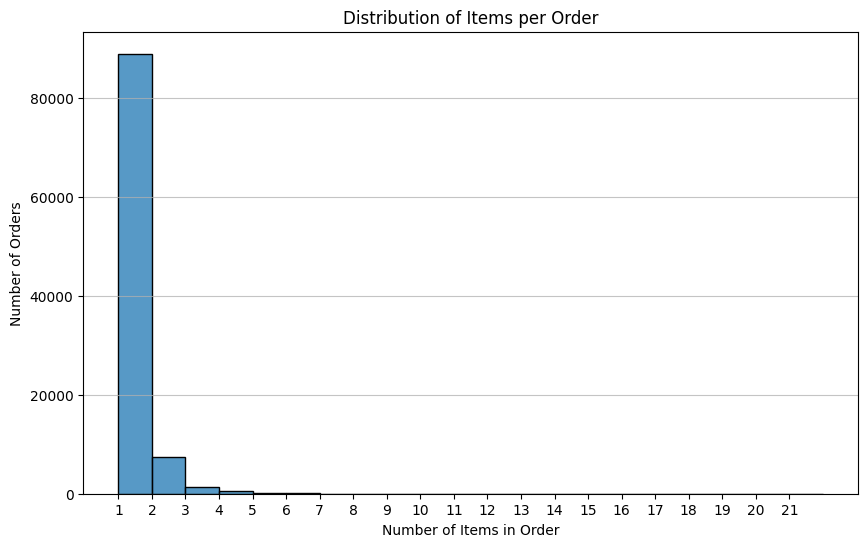

,item_count,order_count
0,1,88863
1,2,7516
2,3,1322
3,4,505
4,5,204
5,6,198
6,7,22
7,8,8
8,9,3
9,10,8


In [ ]:
items_per_order = (
    df_order_items
    .groupby('order_id')['order_item_id']
    .count()
    .reset_index(name='item_count')
)

item_distribution = (
    items_per_order['item_count']
    .value_counts()
    .sort_index()
    .reset_index()
)

item_distribution.columns = ['item_count', 'order_count']

plt.figure(figsize=(10, 6))
sns.histplot(items_per_order['item_count'], bins=range(1, items_per_order['item_count'].max() + 2), kde=False)
plt.title('Distribution of Items per Order')
plt.xlabel('Number of Items in Order')
plt.ylabel('Number of Orders')
plt.xticks(range(1, items_per_order['item_count'].max() + 1))
plt.grid(axis='y', alpha=0.75)
plt.show()

item_distribution

### 3.5 Order Payment Dataset

In [ ]:
df_order_payment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [ ]:
df_order_payment.isna().sum()

,0
order_id,0
payment_sequential,0
payment_type,0
payment_installments,0
payment_value,0


In [ ]:
df_order_payment['payment_type'].value_counts(normalize=True) * 100

,proportion
payment_type,
credit_card,73.922376
boleto,19.043952
voucher,5.558978
debit_card,1.471806
not_defined,0.002888


### 3.6 Order Review Dataset

In [ ]:
df_order_review.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [ ]:
df_order_review['review_creation_date']   = pd.to_datetime(df_order_review['review_creation_date'])
df_order_review['review_answer_timestamp'] = pd.to_datetime(df_order_review['review_answer_timestamp'])

🚀 **Task 2**. 응답 시간 (response_time)

- 리뷰 작성 → 판매자 응답까지 걸린 시간을 계산합니다.

In [ ]:
# Write your code here
df_order_review['response_time'] = (
    df_order_review['review_answer_timestamp'] - df_order_review['review_creation_date']
)

In [ ]:
avg_response_time = df_order_review['response_time'].mean()

print("평균 응답 시간:", avg_response_time)

평균 응답 시간: 3 days 03:34:33.029700475


### 3.7 Orders Dataset

In [ ]:
df_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [ ]:
df_orders.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


In [ ]:
date_cols = ['order_purchase_timestamp', 'order_approved_at',
             'order_delivered_carrier_date', 'order_delivered_customer_date',
             'order_estimated_delivery_date']
for col in date_cols:
    df_orders[col] = pd.to_datetime(df_orders[col])

In [ ]:
for col in date_cols:
    df_orders = df_orders.dropna(subset=col)

### 3.8 Geolocation Dataset

In [ ]:
df_location.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


# 4️⃣ Features Engineering

시간 정보 추출하기

In [ ]:
df_orders['purchase_year'] = df_orders['order_purchase_timestamp'].dt.year
df_orders['purchase_month'] = df_orders['order_purchase_timestamp'].dt.strftime('%Y-%m')
df_orders['purchase_day_of_week'] = df_orders['order_purchase_timestamp'].dt.day_name()

부피 피처 생성하기

In [ ]:
df_products_eng['product_volume_cm3'] = (
    df_products_eng['product_length_cm'] *
    df_products_eng['product_height_cm'] *
    df_products_eng['product_width_cm']
)

🚀 **Task 3**. 배송 지연 여부 (`is_late`)

- 원본 데이터셋만으로는 배송이 실제로 지연되었는지 바로 파악하기 어렵습니다. 배송 지연 여부를 나타내는 컬럼은 어떻게 생성할 수 있을까요?

- 실제 배송에 걸린 기간을 의미하는 `delivery_days` 변수도 함께 생성해 보세요.

In [ ]:
# Write your code here

# 1. 실제 배송 소요 기간 (도착일 - 구매일)
df_orders['delivery_days'] = (df_orders['order_delivered_customer_date'] - df_orders['order_purchase_timestamp']).dt.total_seconds() / 86400

# 2. 지연 여부
df_orders['is_late'] = (df_orders['order_delivered_customer_date'] - df_orders['order_estimated_delivery_date']).dt.total_seconds().apply(lambda x: 1 if x > 3600 else 0)

# 5️⃣ Merging All Datasets

In [ ]:
# 0. 같은 주문 내 동일 상품(product_id) 중복은 첫 번째 행만 남기기
#    order_item_id 기준으로 정렬 후 첫 행 유지
order_items_dedup = (
    df_order_items
    .sort_values(['order_id', 'product_id', 'order_item_id'])
    .drop_duplicates(subset=['order_id', 'product_id'], keep='first')
)

# 1. Starting with the Orders table
df_merged = pd.merge(df_orders, order_items_dedup, on='order_id', how='left')

# 2. Merging Products
df_merged = pd.merge(df_merged, df_products_eng, on='product_id', how='left')

# 3. Merging Sellers
df_merged = pd.merge(df_merged, df_sellers, on='seller_id', how='left')

# 4. Merging Customers
df_merged = pd.merge(df_merged, df_customer, on='customer_id', how='left')

In [ ]:
review_agg = (df_order_review.groupby('order_id', as_index=False).agg(review_score=('review_score', 'first')))
df_merged = pd.merge(df_merged, review_agg, on='order_id', how='left')


- 같은 주문에 리뷰가 여러 개 있을 수 있으므로 review_score의 첫번째 값을 대표 값으로 만듭니다.

In [ ]:
payment_agg = df_order_payment.groupby('order_id')['payment_value'].sum().reset_index()
payment_agg.rename(columns={'payment_value': 'total_order_value'}, inplace=True)
df_merged = pd.merge(df_merged, payment_agg, on='order_id', how='left')


*   한 주문에 여러 결제 방법이 섞일 수 있으므로, order_id 기준으로 payment_value를 합산합니다.



In [ ]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100180 entries, 0 to 100179
Data columns (total 39 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       100180 non-null  object        
 1   customer_id                    100180 non-null  object        
 2   order_status                   100180 non-null  object        
 3   order_purchase_timestamp       100180 non-null  datetime64[ns]
 4   order_approved_at              100180 non-null  datetime64[ns]
 5   order_delivered_carrier_date   100180 non-null  datetime64[ns]
 6   order_delivered_customer_date  100180 non-null  datetime64[ns]
 7   order_estimated_delivery_date  100180 non-null  datetime64[ns]
 8   purchase_year                  100180 non-null  int32         
 9   purchase_month                 100180 non-null  object        
 10  purchase_day_of_week           100180 non-null  object        
 11  

In [ ]:
pd.set_option('display.max_columns', None)
print("pandas 'display.max_columns' option has been set to None (display all columns).")

pandas 'display.max_columns' option has been set to None (display all columns).


In [ ]:
display(df_merged.head(10))

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_year,purchase_month,purchase_day_of_week,delivery_days,is_late,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,freight_ratio,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,product_volume_cm3,seller_zip_code_prefix,seller_city,seller_state,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,review_score,total_order_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,2017-10,Monday,8.436574,0,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,0.290764,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares,1976.0,9350,maua,SP,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,4.0,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018,2018-07,Tuesday,13.782037,0,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,0.191744,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,perfumery,4693.0,31570,belo horizonte,SP,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,4.0,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018,2018-08,Wednesday,9.394213,0,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,0.120200,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,auto,9576.0,14840,guariba,SP,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,5.0,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017,2017-11,Saturday,13.208750,0,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,0.604444,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0,pet_shop,6000.0,31842,belo horizonte,MG,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,5.0,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018,2018-02,Tuesday,2.873877,0,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,0.438191,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0,stationery,11475.0,8752,mogi das cruzes,SP,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,5.0,28.62
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01,2017,2017-07,Sunday,16.542245,0,1,060cb19345d90064d1015407193c233d,8581055ce74af1daba164fdbd55a40de,2017-07-13 22:10:13,147.90,27.36,0.184990,automotivo,49.0,608.0,1.0,7150.0,65.0,10.0,65.0,auto,42250.0,7112,guarulhos,SP,80bb27c7c16e8f973207a5086ab329e2,86320,congonhinhas,PR,4.0,175.26
6,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,2017-06-07,2017,2017-05,Tuesday,9.989826,0,1,4520766ec412348b8d4caa5e8a18c464,16090f2ca825584b5a147ab24aa30c86,2017-05-22 13:22:11,59.99,15.17,0.252875,automotivo,59.0,956.0,1.0,50.0,16.0,16.0,17.0,auto,4352.0,12940,atibaia,SP,932afa1e708222e5821dac9cd5db4cae,26525,nilopolis,RJ,5.0,75.16
7,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,delivered,2017-01-23 18:29:09,2017-

### 🚀 Task: 결측치 처리

테이블 병합 과정에서 새로운 결측치가 발생할 수 있습니다. 적절한 방법으로 결측치를 처리해보세요.

In [ ]:
df_merged.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,0
order_delivered_carrier_date,0
order_delivered_customer_date,0
order_estimated_delivery_date,0
purchase_year,0
purchase_month,0


In [ ]:
# Write your code here
temp_cols = ['product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'product_volume_cm3', 'review_score', 'total_order_value']

df_merged = df_merged.dropna(subset=temp_cols)

df_merged['product_category_name'] = df_merged['product_category_name'].fillna('Unknown')
df_merged['product_category_name_english'] = df_merged['product_category_name_english'].fillna('Unknown')

In [ ]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
Index: 98095 entries, 0 to 100179
Data columns (total 39 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       98095 non-null  object        
 1   customer_id                    98095 non-null  object        
 2   order_status                   98095 non-null  object        
 3   order_purchase_timestamp       98095 non-null  datetime64[ns]
 4   order_approved_at              98095 non-null  datetime64[ns]
 5   order_delivered_carrier_date   98095 non-null  datetime64[ns]
 6   order_delivered_customer_date  98095 non-null  datetime64[ns]
 7   order_estimated_delivery_date  98095 non-null  datetime64[ns]
 8   purchase_year                  98095 non-null  int32         
 9   purchase_month                 98095 non-null  object        
 10  purchase_day_of_week           98095 non-null  object        
 11  delivery_days      

# 6️⃣ Exploratory Data Analysis (EDA)

In [ ]:
# Visualization libraries
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from plotly.offline import init_notebook_mode
init_notebook_mode(connected=True)

## 고객 분석

### 신규 고객 VS 재구매 고객

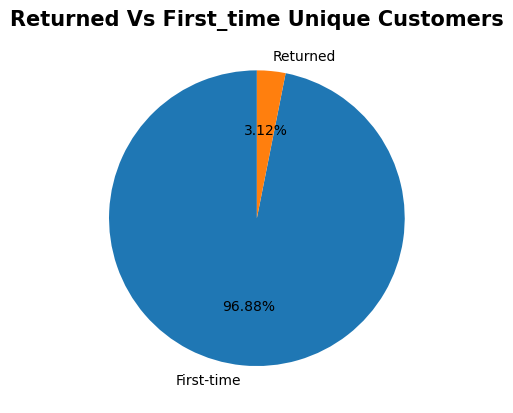

In [ ]:
unique_customer_counts = df_customer['customer_unique_id'].value_counts()

customer_type_labels = unique_customer_counts.apply(lambda x: 'Returned' if x > 1 else 'First-time')

customer_type_distribution = customer_type_labels.value_counts()

plt.title("Returned Vs First_time Unique Customers",fontdict={'fontsize':15,'fontweight':600})
plt.pie(customer_type_distribution,normalize=True,startangle=90,
        labels=customer_type_distribution.index,autopct='%1.2f%%')
plt.show()

💡 Insight

- 약 96.88%의 고객이 첫 구매자이다.

- 재구매 고객은 3.12%에 불과해, 고객 충성도와 유지에 어려움이 있음을 시사한다.

- 구매 후 사용자 경험과 배송 신뢰도를 향상시키면 첫 구매 고객을 재구매 고객으로 전환하는 데 도움이 될 수 있다.

In [ ]:
# 1. df_merged에서 주문 단위 중복 제거
#    주문별로 고객, 구매월, 주문금액만 남김
df_temp = df_merged[['order_id', 'customer_unique_id', 'purchase_month', 'total_order_value']].drop_duplicates(subset=['order_id']).copy()

# 2. purchase_month를 datetime으로 변환
df_temp['order_month'] = pd.to_datetime(df_temp['purchase_month'])

# 3. 고객별 첫 구매월 계산
df_temp['first_purchase_month'] = df_temp.groupby('customer_unique_id')['order_month'].transform('min')

# 4. 신규 고객 여부 판별
df_temp['is_new'] = df_temp['order_month'].eq(df_temp['first_purchase_month'])

# 5. 월별 신규 고객 수 / 신규 고객 매출
new_monthly = df_temp[df_temp['is_new']].groupby('order_month').agg(
    new_customers_count=('customer_unique_id', 'nunique'),
    new_customers_value=('total_order_value', 'sum')
)

# 6. 월별 재구매 고객 수
return_monthly = df_temp[~df_temp['is_new']].groupby('order_month').agg(
    return_customers_count=('customer_unique_id', 'nunique')
)

# 7. 월별 시계열 테이블 생성
data_customer_timeseries = pd.concat([new_monthly, return_monthly], axis=1).fillna(0).reset_index().rename(columns={'order_month': 'year_month'}).sort_values('year_month')

# 8. 표시용 문자열 변환
data_customer_timeseries['year_month'] = data_customer_timeseries['year_month'].dt.strftime('%Y-%m')

# 9. 시각화
fig = go.Figure()
fig.add_trace(go.Bar(
    x=data_customer_timeseries["year_month"],
    y=data_customer_timeseries["new_customers_count"],
    name="Number of new customers",
    marker_color="mediumaquamarine"
))
fig.add_trace(go.Bar(
    x=data_customer_timeseries["year_month"],
    y=data_customer_timeseries["return_customers_count"],
    name="Number of returned customers",
    marker_color="powderblue"
))
fig.add_trace(go.Scatter(
    x=data_customer_timeseries["year_month"],
    y=data_customer_timeseries["new_customers_value"],
    name="Revenue from new customers",
    yaxis="y2",
    marker_color="indianred",
    mode="lines+markers"
))
fig.update_layout(
    title=dict(
        text="<b>New Customers And Return Customers By Month</b>",
        font=dict(size=12, family="Arial", color="black")
    ),
    plot_bgcolor="white",
    barmode="stack",
    yaxis=dict(side="left", showgrid=False, zeroline=True, showline=False, showticklabels=False),
    yaxis2=dict(side="right", overlaying="y", showgrid=False, zeroline=False, showline=False, showticklabels=False),
    xaxis=dict(showline=True, linecolor="rgb(204, 204, 204)", linewidth=2),
    legend=dict(orientation="h"),
    hovermode="x unified",
    annotations=[dict(
        text="Created By Thuan Dao.",
        xref="paper", yref="paper",
        x=1.05, y=-0.25,
        showarrow=False,
        font=dict(size=10, color="gray", family="Arial")
    )]
)
fig.show(renderer="colab")

💡 Insight
- 2017년 신규 고객 유치에 큰 성공을 거두었으며 주요 매출원이 되었다.
- 2017년부터 2018년 초까지 신규 고객 수가 꾸준히 증가하다가 2018년 중반 이후 감소하는 경향을 보인다.
- 신규 고객으로부터 발생하는 매출이 전체 매출에 상당한 부분을 차지하고 있어, 신규 고객 확보가 매출 성장에 중요한 요소임을 알 수 있다.

# 자유롭게 분석해보세요~

In [ ]:
# 주(State)별 집계
state_market = df_merged.groupby('customer_state').agg({
    'price': 'sum',                      # 순수 매출액
    'order_id': 'nunique',               # 총 주문 건수
    'customer_unique_id': 'nunique',    # 실제 고객 수
    'freight_value': 'mean',             # 평균 배송비
    'review_score': 'mean'               # 평균 만족도
}).rename(columns={'price': 'total_sales'})

# 고객당 평균 결제액(AOV) 계산
state_market['AOV'] = state_market['total_sales'] / state_market['order_id']

# 매출액 기준 내림차순 정렬
state_market = state_market.sort_values(by='total_sales', ascending=False)
print(state_market.head(10))

                total_sales  order_id  customer_unique_id  freight_value  \
customer_state                                                             
SP               4667916.27     39724               38425      15.234078   
RJ               1598085.33     12035               11623      21.042749   
MG               1431317.90     11119               10781      20.774337   
RS                669914.03      5248                5074      21.826711   
PR                609454.56      4832                4682      20.555685   
SC                457679.62      3465                3372      21.742798   
BA                449570.49      3189                3095      26.375118   
DF                279262.37      2040                1980      21.364691   
GO                251829.87      1900                1839      22.993927   
ES                239086.49      1952                1889      22.056398   

                review_score         AOV  
customer_state                            
S

In [ ]:
# 1. 주별 유니크한 주문 건수 계산
state_counts = df_merged.groupby('customer_state')['order_id'].nunique()

# 2. 전체 주문 건수로 나누어 비율(%) 계산
state_ratios = (state_counts / state_counts.sum()) * 100

# 3. 보기 좋게 데이터프레임으로 정리 및 내림차순 정렬
state_ratios_df = state_ratios.reset_index().rename(columns={'order_id': 'order_ratio(%)'})
state_ratios_df = state_ratios_df.sort_values(by='order_ratio(%)', ascending=False)

print(state_ratios_df)

   customer_state  order_ratio(%)
25             SP       42.040428
18             RJ       12.736798
10             MG       11.767383
22             RS        5.554027
17             PR        5.113769
23             SC        3.667055
4              BA        3.374960
6              DF        2.158959
7              ES        2.065827
8              GO        2.010795
15             PE        1.653085
5              CE        1.332416
13             PA        0.969415
12             MT        0.918616
9              MA        0.743994
11             MS        0.730236
14             PB        0.533390
19             RN        0.492116
16             PI        0.491057
1              AL        0.412742
24             SE        0.351360
26             TO        0.285745
20             RO        0.250820
2              AM        0.151339
0              AC        0.082548
3              AP        0.069849
21             RR        0.041274


/tmp/ipykernel_1130/828715008.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




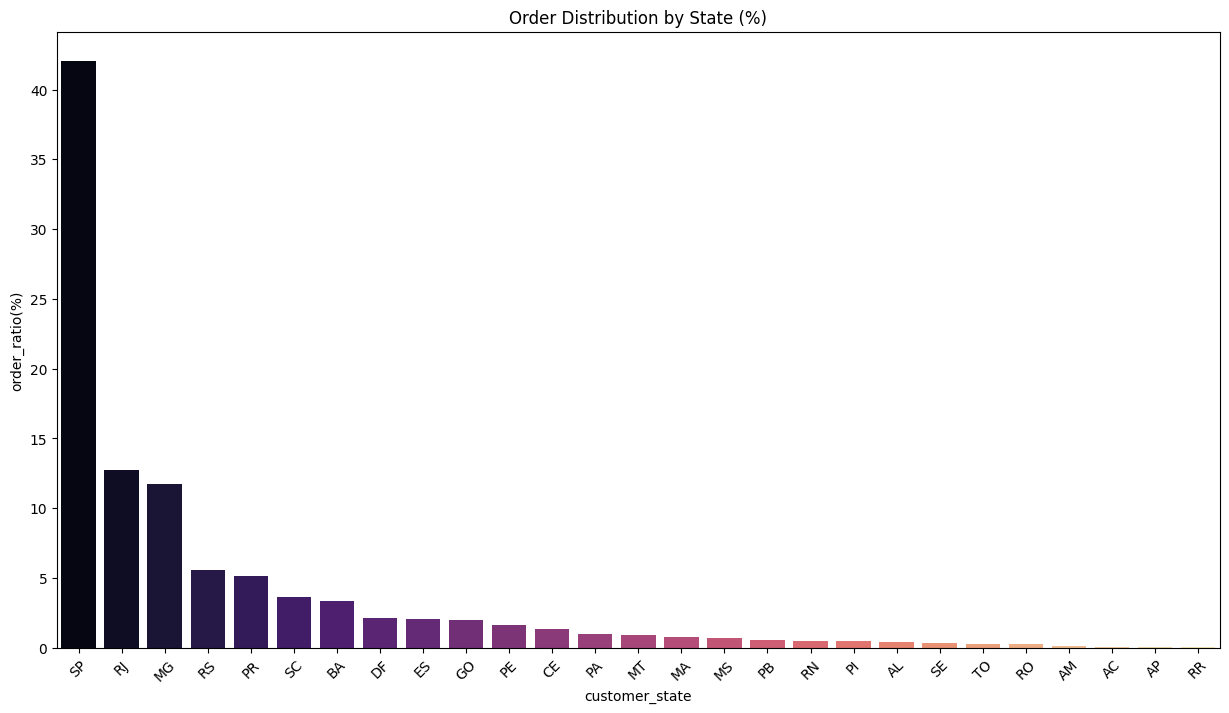

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 8))
sns.barplot(data=state_ratios_df, x='customer_state', y='order_ratio(%)', palette='magma')
plt.title('Order Distribution by State (%)')
plt.xticks(rotation=45) # 주 이름이 겹치지 않게 회전
plt.show()

In [ ]:
# 1. 주(State)별 총 주문 건수와 지연 건수 집계
delay_stats = df_merged.groupby('customer_state').agg(
    total_orders=('order_id', 'nunique'),  # 총 주문 건수
    late_orders=('is_late', 'sum')         # 지연된 주문 건수 (is_late가 1인 경우의 합)
).reset_index()

# 2. 지연율(%) 계산
delay_stats['delay_rate(%)'] = (delay_stats['late_orders'] / delay_stats['total_orders']) * 100

# 3. 지연율 기준으로 내림차순 정렬 (가장 심각한 지역부터 보기)
delay_stats = delay_stats.sort_values(by='delay_rate(%)', ascending=False)

# 4. 결과 확인 (상위 10개 지역)
print(delay_stats.head(10))

   customer_state  total_orders  late_orders  delay_rate(%)
1              AL           390           92      23.589744
9              MA           703          142      20.199147
16             PI           464           76      16.379310
5              CE          1259          191      15.170770
24             SE           332           50      15.060241
4              BA          3189          447      14.016933
18             RJ         12035         1631      13.552140
21             RR            39            5      12.820513
26             TO           270           34      12.592593
13             PA           916          112      12.227074


/tmp/ipykernel_1130/4121607278.py:9: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




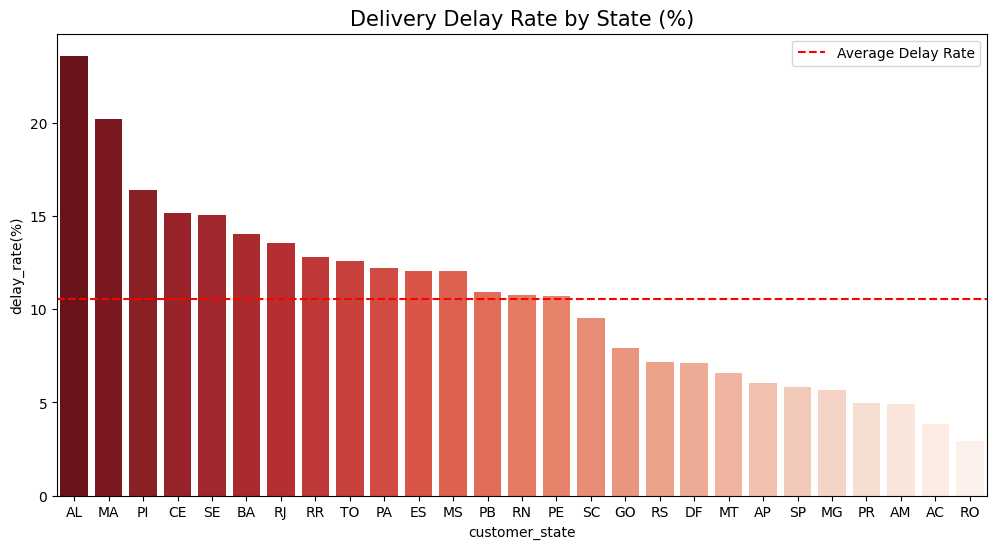

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 주문 건수가 너무 적은 지역(예: 100건 미만)을 제외하고 유의미한 데이터만 필터링하는 것도 좋습니다.
# valid_delay_stats = delay_stats[delay_stats['total_orders'] >= 100]

plt.figure(figsize=(12, 6))
# 지연율이 높은 순서대로 붉은색 그라데이션 적용
sns.barplot(data=delay_stats, x='customer_state', y='delay_rate(%)', palette='Reds_r')
plt.title('Delivery Delay Rate by State (%)', fontsize=15)
plt.axhline(delay_stats['delay_rate(%)'].mean(), color='red', linestyle='--', label='Average Delay Rate') # 전체 평균 지연율 선 긋기
plt.legend()
plt.show()

In [ ]:
# 1. 리뷰 점수별 비율(%) 계산 (기본적으로 비중이 높은 순서대로 내림차순 정렬됨)
review_ratios = df_merged['review_score'].value_counts(normalize=True) * 100

# 전체 비율 확인하기
print("--- 리뷰 점수별 비중(%) ---")
print(review_ratios)
print("\n")

# 2. 세 번째로 높은 점수와 비율 추출 (인덱스는 0부터 시작하므로 2번째 값이 3위)
third_score = review_ratios.index[2]
third_ratio = review_ratios.iloc[2]

print(f"💡 세 번째로 비율이 높은 리뷰 점수는 **{third_score}점**이며, 전체의 **{third_ratio:.2f}%**를 차지합니다.")

--- 리뷰 점수별 비중(%) ---
review_score
5.0    58.611550
4.0    19.469902
1.0    10.333860
3.0     8.375554
2.0     3.209134
Name: proportion, dtype: float64


💡 세 번째로 비율이 높은 리뷰 점수는 **1.0점**이며, 전체의 **10.33%**를 차지합니다.
